In [83]:
"""Load Bradley's MMLU-Pro bucketed dataset and my Qwen judge dataset,
then merge on the shared `problem` text, inspect columns, and plot success
rate distributions vs difficulty buckets."""

from datasets import load_dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import cohen_kappa_score

sns.set_theme(style="whitegrid")

def load_data(current="MATH500"):
    PRO_DATASET_PREFIX = f"pianomoon/{current.lower()}-llama8b-oracle-difficulty"
    PRO_DATASET_VARIANTS = [
        f"{PRO_DATASET_PREFIX}-dev",
        f"{PRO_DATASET_PREFIX}-val",
        f"{PRO_DATASET_PREFIX}-test",
    ]
    QWEN_DATASET = f"pnsahoo/{current}_LLM_judge_fewshot_Qwen_Qwen2_5-7B-Instruct-Turbo"


    def load_split(dataset_id: str, split: str = "train") -> pd.DataFrame:
        ds = load_dataset(dataset_id, split=split)
        return ds.to_pandas()


    def load_many_datasets(dataset_ids, split: str = "data") -> pd.DataFrame:
        """Load several dataset ids (same split) and concat into one DataFrame."""
        frames = [load_split(ds_id, split) for ds_id in dataset_ids]
        return pd.concat(frames, ignore_index=True)


    def load_all_splits(dataset_id: str, splits=("train", "validation", "test")) -> pd.DataFrame:
        frames = [load_split(dataset_id, split) for split in splits]
        return pd.concat(frames, ignore_index=True)


    pro_df = load_many_datasets(PRO_DATASET_VARIANTS)
    qwen_df = load_split(QWEN_DATASET, split="test")

    print("Bradley dataset shape:", pro_df.shape)
    print("My dataset shape:", qwen_df.shape)
    print("\nBradley columns:\n", list(pro_df.columns))
    print("\nMy columns:\n", list(qwen_df.columns))

    return pro_df, qwen_df

In [84]:
# Configure the merge + plotting columns after inspecting the printouts above.
MERGE_KEY = "problem" # "unique_id"
DIFF_COL = "llm_difficulty_fewshot_Qwen_Qwen2_5-7B-Instruct-Turbo"
SCORE_COL = "empirical_difficulty"  # percentile success rate

def get_metrics(pro_df, qwen_df):
    missing = [col for col in [MERGE_KEY] if col not in pro_df.columns or col not in qwen_df.columns]
    if missing:
        raise KeyError(f"Merge key(s) missing from one of the dataframes: {missing}")
    if DIFF_COL not in qwen_df.columns:
        raise KeyError(f"Difficulty bucket column `{DIFF_COL}` not found in qwen_df; set DIFF_COL accordingly.")
    if SCORE_COL not in pro_df.columns:
        raise KeyError(f"Success-rate column `{SCORE_COL}` not found in pro_df; set SCORE_COL accordingly.")

    merged = pro_df.merge(qwen_df, on=MERGE_KEY, how="inner", suffixes=("_bradley", "_qwen"))
    print("Merged shape:", merged.shape)

    return merged

def summarize(merged):
    summary = (
        merged.groupby(DIFF_COL)[SCORE_COL]
        .agg(
            count="count",
            median="median",
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75),
        )
        .reset_index()
    )
    print("\nSummary stats by difficulty bucket:")
    display(summary)

def collapse_difficulty_buckets(df: pd.DataFrame, current="MATH500") -> pd.DataFrame:
    """Collapse difficulty buckets 1/2 -> 1&2 and 4/5 -> 4&5."""
    if current == "MATH500":
        bucket_collapse = {1: "0", 2: "1", 3: "2", 4: "3", 5: "3"}
    else:
        bucket_collapse = {1: "0", 2: "0", 3: "1", 4: "2", 5: "2"} # MMLU, GPQA
    collapsed = df.copy()
    collapsed[DIFF_COL] = collapsed[DIFF_COL].replace(bucket_collapse)
    return collapsed

def correlation_ratio(categories: pd.Series, measurements: pd.Series) -> float:
    """Compute eta-squared (correlation ratio) of categorical X vs continuous Y."""
    valid = measurements.notna() & categories.notna()
    categories = categories[valid]
    measurements = measurements[valid]
    if measurements.empty:
        return float("nan")
    # overall mean
    y_bar = measurements.mean()
    # between-group sum of squares
    ss_between = sum(len(vals) * (vals.mean() - y_bar) ** 2 for _, vals in measurements.groupby(categories))
    # total sum of squares
    ss_total = ((measurements - y_bar) ** 2).sum()
    if ss_total == 0:
        return float("nan")
    return ss_between / ss_total


def compute_agreement(df: pd.DataFrame, current: str):
    """Compute correlations, correlation ratio, and Cohen's kappa."""
    # ensure difficulty is numeric for correlations
    diff_numeric = pd.to_numeric(df[DIFF_COL], errors="coerce")
    score = df[SCORE_COL]

    stats = {
        "pearson": score.corr(diff_numeric, method="pearson"),
        "spearman": score.corr(diff_numeric, method="spearman"),
        "kendall": score.corr(diff_numeric, method="kendall"),
        "corr_ratio": correlation_ratio(df[DIFF_COL], score),
    }

    # Bin oracle scores into 4 quantiles so we can compute Cohen's kappa vs judge buckets
    try:
        score_bins = pd.qcut(score, q=4, labels=["0", "1", "2", "3"])
        kappa = cohen_kappa_score(score_bins, df[DIFF_COL])
    except ValueError:
        # fallback if not enough unique values for qcut
        kappa = float("nan")

    print(f"\nAgreement metrics for {current}:")
    for name, val in stats.items():
        print(f"  {name}: {val:.4f}")
    print(f"  cohen_kappa (score quartiles vs judge buckets): {kappa:.4f}")

    return {**stats, "cohen_kappa": kappa}


def plot(merged, name="MATH500"):
    order = sorted(merged[DIFF_COL].unique())
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=merged, x=DIFF_COL, y=SCORE_COL, order=order, showfliers=False, palette="Set2")
    plt.title(f"Oracle Difficulty vs LLM-as-a-Judge Difficulty Bucket on {name}")
    plt.xlabel("Difficulty Bucket")
    plt.ylabel("Oracle Success Rate")
    plt.tight_layout()
    plt.savefig(f"oracle_vs_judge_{name}.png")
    plt.show()
    

def plot_oracle(pro_df, current):
    pro_df[SCORE_COL].hist(color="darkblue", alpha=0.8)
    plt.xlabel("Oracle Success Rate")
    plt.ylabel("Count")
    plt.title(f"Verifier Success Rate Histogram for {current}")
    plt.savefig(f"oracle_hist_{current}.png")
    plt.show()

Bradley dataset shape: (500, 30)
My dataset shape: (500, 8)

Bradley columns:
 ['instruction', 'level', 'answer', 'samples', 'extracted_answers', 'answer_correct', 'ArmorRM_scores', 'GPM_scores', 'internlm_scores', 'GRMLlama32_scores', 'OffsetBias_scores', 'GRMGemma_scores', 'Skyworks_scores', 'URM_scores', 'QRM_scores', 'EurusPRMStage2_min_scores', 'EurusPRMStage2_max_scores', 'EurusPRMStage2_avg_scores', 'InternLM2Reward7B_scores', 'GRM_scores', 'EurusPRMStage1_min_scores', 'EurusPRMStage1_max_scores', 'EurusPRMStage1_avg_scores', 'QwenPRM_min_scores', 'QwenPRM_max_scores', 'QwenPRM_avg_scores', 'weaver_scores', 'unique_id', 'cluster_id', 'empirical_difficulty']

My columns:
 ['problem', 'solution', 'answer', 'subject', 'level', 'unique_id', 'llm_difficulty_fewshot_Qwen_Qwen2_5-7B-Instruct-Turbo', 'llm_difficulty_fewshot_Qwen_Qwen2_5-7B-Instruct-Turbo-amended']


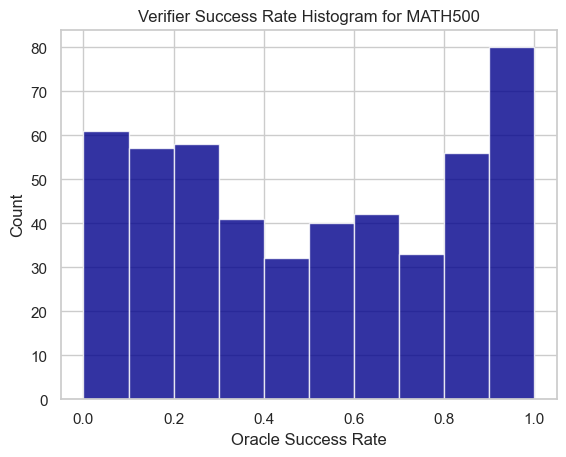

Merged shape: (500, 37)

Summary stats by difficulty bucket:


,llm_difficulty_fewshot_Qwen_Qwen2_5-7B-Instruct-Turbo,count,median,q1,q3
0,0,80,0.865,0.6875,0.9425
1,1,183,0.680,0.3850,0.8700
2,2,111,0.350,0.1400,0.5650
3,3,126,0.200,0.0800,0.3775



Agreement metrics for MATH500:
  pearson: -0.5584
  spearman: -0.5604
  kendall: -0.4375
  corr_ratio: 0.3159
  cohen_kappa (score quartiles vs judge buckets): -0.1200


/var/folders/dk/l00s44td6p7cjddt9mw1qypr0000gn/T/ipykernel_40900/143352342.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x=DIFF_COL, y=SCORE_COL, order=order, showfliers=False, palette="Set2")


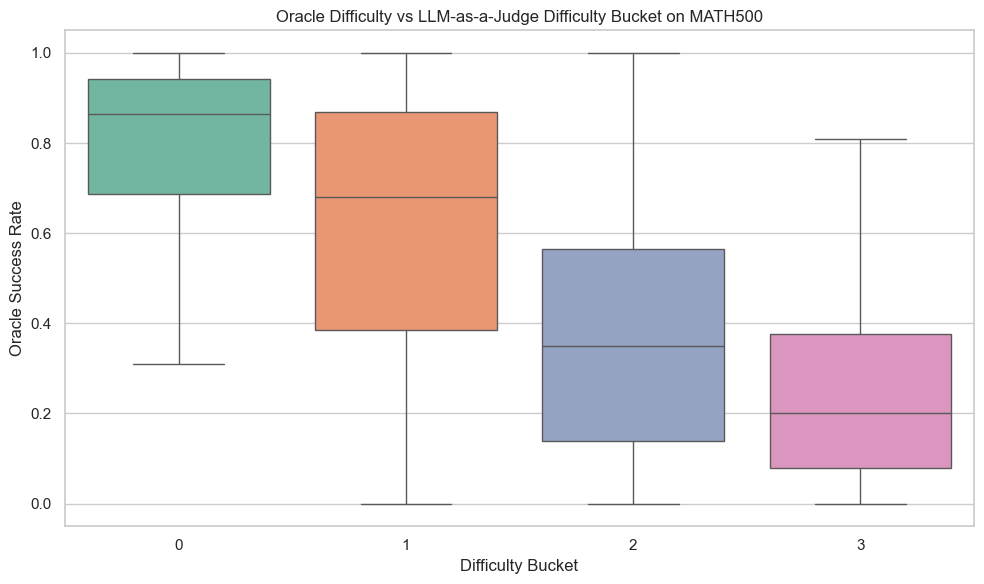

In [86]:
current = "MATH500"
MERGE_KEY = "unique_id"

pro_df, qwen_df = load_data(current)
plot_oracle(pro_df, current)

collapsed = collapse_difficulty_buckets(get_metrics(pro_df, qwen_df), current)
summarize(collapsed)
compute_agreement(collapsed, current)
plot(collapsed, current)

Bradley dataset shape: (646, 37)
My dataset shape: (646, 35)

Bradley columns:
 ['original_instruction', 'problem', 'level', 'type', 'options', 'solution', 'correct_answer', 'options_original_order', 'answer', 'subject', 'instruction', 'samples', 'extracted_answers', 'answer_correct', 'GRM_scores', 'Skyworks_scores', 'URM_scores', 'QRM_scores', 'GPM_scores', 'GRMLlama32_scores', 'OffsetBias_scores', 'GRMGemma_scores', 'ArmorRM_scores', 'QwenPRM_min_scores', 'QwenPRM_max_scores', 'QwenPRM_avg_scores', 'EurusPRMStage1_min_scores', 'EurusPRMStage1_max_scores', 'EurusPRMStage1_avg_scores', 'EurusPRMStage2_min_scores', 'EurusPRMStage2_max_scores', 'EurusPRMStage2_avg_scores', 'InternLM2Reward7B_scores', 'weaver_scores', 'unique_id', 'cluster_id', 'empirical_difficulty']

My columns:
 ['original_instruction', 'problem', 'level', 'type', 'options', 'solution', 'correct_answer', 'options_original_order', 'answer', 'subject', 'instruction', 'samples', 'extracted_answers', 'answer_correct', 'GRM

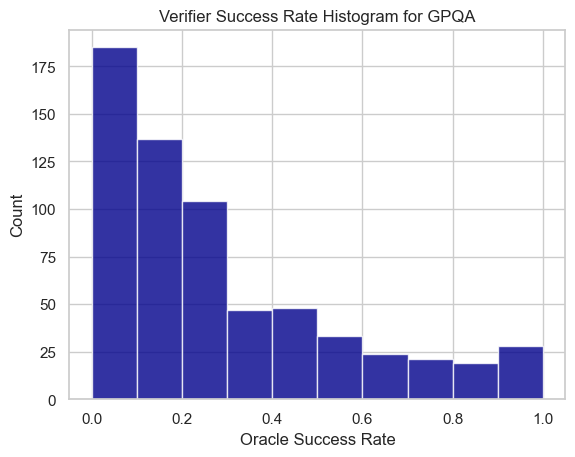

Merged shape: (662, 71)

Summary stats by difficulty bucket:


,llm_difficulty_fewshot_Qwen_Qwen2_5-7B-Instruct-Turbo,count,median,q1,q3
0,0,77,0.17,0.06,0.4800
1,1,226,0.20,0.08,0.4875
2,2,359,0.20,0.09,0.3700



Agreement metrics for GPQA:
  pearson: -0.0792
  spearman: -0.0107
  kendall: -0.0094
  corr_ratio: 0.0080
  cohen_kappa (score quartiles vs judge buckets): 0.0115


/var/folders/dk/l00s44td6p7cjddt9mw1qypr0000gn/T/ipykernel_40900/143352342.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x=DIFF_COL, y=SCORE_COL, order=order, showfliers=False, palette="Set2")


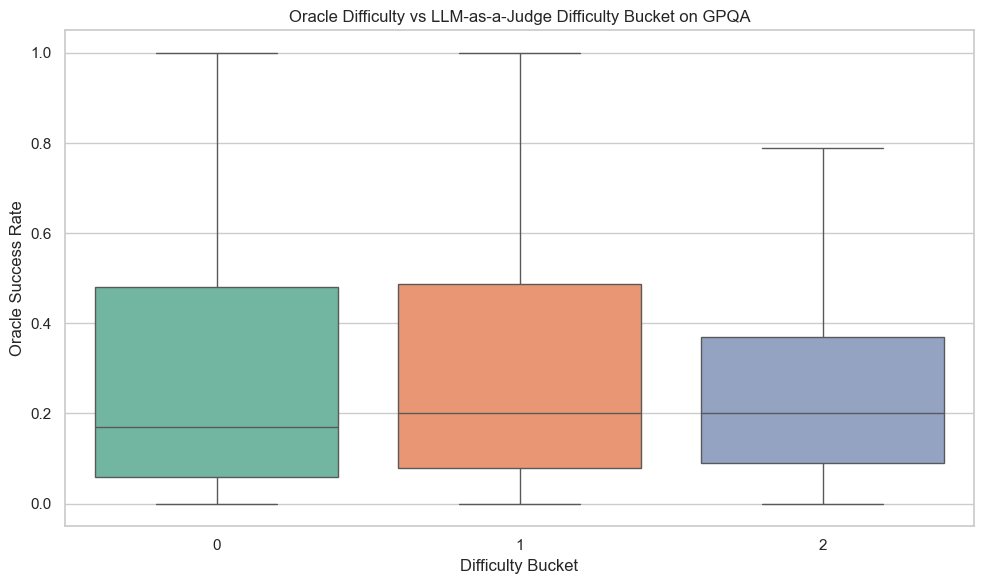

In [87]:
current = "GPQA"
MERGE_KEY = "problem"

pro_df, qwen_df = load_data(current)
plot_oracle(pro_df, current)

collapsed = collapse_difficulty_buckets(get_metrics(pro_df, qwen_df), current)
summarize(collapsed)
compute_agreement(collapsed, current)

plot(collapsed, current)

Bradley dataset shape: (719, 30)
My dataset shape: (719, 28)

Bradley columns:
 ['instruction', 'problem', 'choices', 'answer', 'samples', 'extracted_answers', 'answer_correct', 'InternLM2Reward7B_scores', 'GRMLlama32_scores', 'GRMGemma_scores', 'GRM_scores', 'URM_scores', 'QRM_scores', 'ArmorRM_scores', 'GPM_scores', 'OffsetBias_scores', 'Skyworks_scores', 'EurusPRMStage1_min_scores', 'EurusPRMStage1_max_scores', 'EurusPRMStage1_avg_scores', 'EurusPRMStage2_min_scores', 'EurusPRMStage2_max_scores', 'EurusPRMStage2_avg_scores', 'QwenPRM_min_scores', 'QwenPRM_max_scores', 'QwenPRM_avg_scores', 'weaver_scores', 'unique_id', 'cluster_id', 'empirical_difficulty']

My columns:
 ['instruction', 'problem', 'choices', 'answer', 'samples', 'extracted_answers', 'answer_correct', 'InternLM2Reward7B_scores', 'GRMLlama32_scores', 'GRMGemma_scores', 'GRM_scores', 'URM_scores', 'QRM_scores', 'ArmorRM_scores', 'GPM_scores', 'OffsetBias_scores', 'Skyworks_scores', 'EurusPRMStage1_min_scores', 'EurusPRM

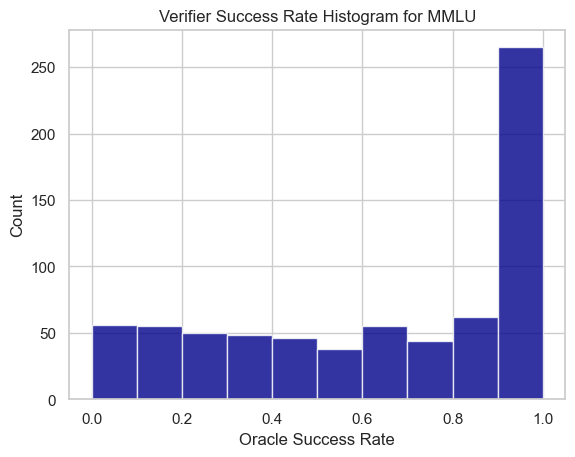

Merged shape: (761, 57)

Summary stats by difficulty bucket:


,llm_difficulty_fewshot_Qwen_Qwen2_5-7B-Instruct-Turbo,count,median,q1,q3
0,0,86,0.840,0.3525,0.99
1,1,414,0.845,0.4500,0.99
2,2,261,0.540,0.2500,0.82



Agreement metrics for MMLU:
  pearson: -0.1918
  spearman: -0.2357
  kendall: -0.1902
  corr_ratio: 0.0578
  cohen_kappa (score quartiles vs judge buckets): -0.0419


/var/folders/dk/l00s44td6p7cjddt9mw1qypr0000gn/T/ipykernel_40900/143352342.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x=DIFF_COL, y=SCORE_COL, order=order, showfliers=False, palette="Set2")


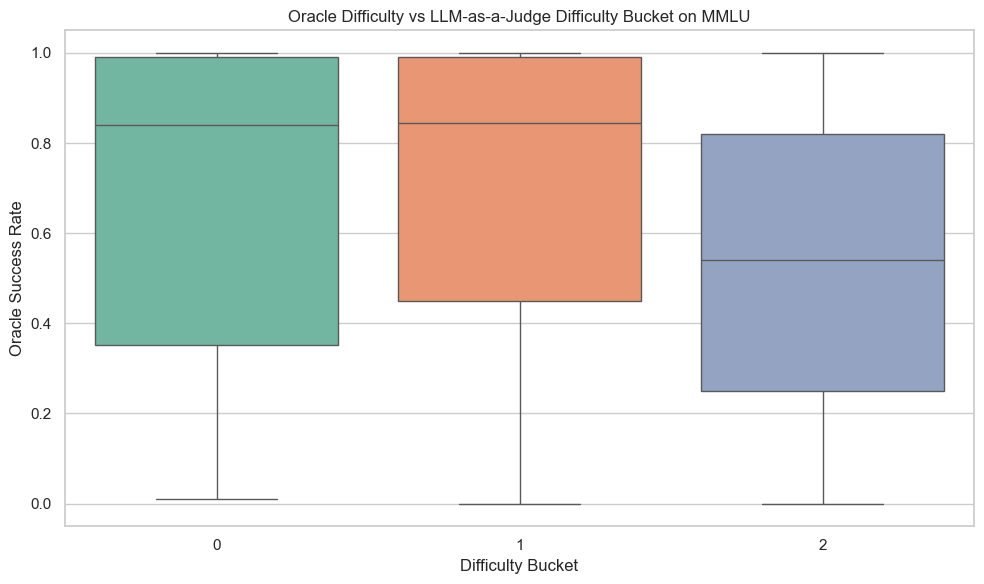

In [88]:
current = "MMLU"

pro_df, qwen_df = load_data(current)
plot_oracle(pro_df, current)

collapsed = collapse_difficulty_buckets(get_metrics(pro_df, qwen_df), current)
summarize(collapsed)
compute_agreement(collapsed, current)
plot(collapsed, current)

In [ ]:
collapsed[SCORE_COL].corr(collapsed[DIFF_COL])

np.float64(-0.1917667085824566)

In [78]:
collapsed.columns

Index(['instruction_bradley', 'problem', 'choices_bradley', 'answer_bradley',
       'samples_bradley', 'extracted_answers_bradley',
       'answer_correct_bradley', 'InternLM2Reward7B_scores_bradley',
       'GRMLlama32_scores_bradley', 'GRMGemma_scores_bradley',
       'GRM_scores_bradley', 'URM_scores_bradley', 'QRM_scores_bradley',
       'ArmorRM_scores_bradley', 'GPM_scores_bradley',
       'OffsetBias_scores_bradley', 'Skyworks_scores_bradley',
       'EurusPRMStage1_min_scores_bradley',
       'EurusPRMStage1_max_scores_bradley',
       'EurusPRMStage1_avg_scores_bradley',
       'EurusPRMStage2_min_scores_bradley',
       'EurusPRMStage2_max_scores_bradley',
       'EurusPRMStage2_avg_scores_bradley', 'QwenPRM_min_scores_bradley',
       'QwenPRM_max_scores_bradley', 'QwenPRM_avg_scores_bradley',
       'weaver_scores_bradley', 'unique_id', 'cluster_id',
       'empirical_difficulty', 'instruction_qwen', 'choices_qwen',
       'answer_qwen', 'samples_qwen', 'extracted_answers_

In [79]:
collapsed['cluster_id']

0      3
1      4
2      0
3      0
4      4
      ..
756    0
757    0
758    0
759    4
760    2
Name: cluster_id, Length: 761, dtype: int64